# Spectral Clustering of Pan-Cancer Gene Expression

Performs spectral clustering (K=20) on the pan-cancer gene expression dataset and visualises the result using t-SNE.  
Cancer type labels are overlaid for biological reference.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# ── Configuration ─────────────────────────────────────────────────────────────
K    = 12        # number of spectral clusters
SEED = 42
# ──────────────────────────────────────────────────────────────────────────────

GE_FILE = "pan_cancer/gene_expression.csv"
CT_FILE = "pan_cancer/cancertype.csv"

## Load Data

In [11]:
ge = pd.read_csv(GE_FILE, index_col=0)   # (N, n_genes)
ct = pd.read_csv(CT_FILE, index_col=0)   # (N, 1) cancer type

print(f"Gene expression shape: {ge.shape}")
print(f"Cancer types ({ct['cancertype'].nunique()}): {sorted(ct['cancertype'].unique())}")

Gene expression shape: (2617, 1247)
Cancer types (12): ['BLCA', 'BRCA', 'COAD', 'GBM', 'HNSC', 'KIRC', 'LAML', 'LUAD', 'LUSC', 'OV', 'READ', 'UCEC']


## PCA Pre-processing

Standardise features and reduce to 50 principal components before spectral clustering and t-SNE.  
This keeps computation tractable and removes low-variance noise.

In [12]:
scaler = StandardScaler()
ge_scaled = scaler.fit_transform(ge.values)

pca = PCA(n_components=50, random_state=SEED)
ge_pca = pca.fit_transform(ge_scaled)

print(f"Explained variance (50 PCs): {pca.explained_variance_ratio_.sum():.2%}")

Explained variance (50 PCs): 73.05%


## Spectral Clustering

Uses an RBF (Gaussian) affinity kernel on the PCA-reduced data.  
The `nearest_neighbors` affinity can be faster for large N — switch if needed.

In [39]:
K = 20
print(f"Running SpectralClustering with K={K} ...")
sc = SpectralClustering(
    n_clusters=K,
    affinity="nearest_neighbors",
    n_neighbors=15,
    assign_labels="kmeans",
    random_state=SEED,
    n_jobs=-1,
)
labels = sc.fit_predict(ge_pca)   # integer labels 0 .. K-1

unique, counts = np.unique(labels, return_counts=True)
print("Cluster sizes:")
for u, c in zip(unique, counts):
    print(f"  Cluster {u:2d}: {c} samples")

Running SpectralClustering with K=20 ...


c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Cluster sizes:
  Cluster  0: 100 samples
  Cluster  1: 75 samples
  Cluster  2: 237 samples
  Cluster  3: 239 samples
  Cluster  4: 118 samples
  Cluster  5: 212 samples
  Cluster  6: 214 samples
  Cluster  7: 397 samples
  Cluster  8: 200 samples
  Cluster  9: 229 samples
  Cluster 10: 86 samples
  Cluster 11: 55 samples
  Cluster 12: 32 samples
  Cluster 13: 41 samples
  Cluster 14: 88 samples
  Cluster 15: 14 samples
  Cluster 16: 23 samples
  Cluster 17: 37 samples
  Cluster 18: 23 samples
  Cluster 19: 197 samples


## t-SNE Embedding

In [14]:
print("Running t-SNE (this may take ~1 min) ...")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=SEED, n_jobs=-1)
tsne_coords = tsne.fit_transform(ge_pca)
print("Done.")

Running t-SNE (this may take ~1 min) ...
Done.


## Visualisation: Spectral Clusters vs Cancer Type

**Left** — t-SNE coloured by spectral cluster label.  
**Right** — same embedding coloured by known cancer type.

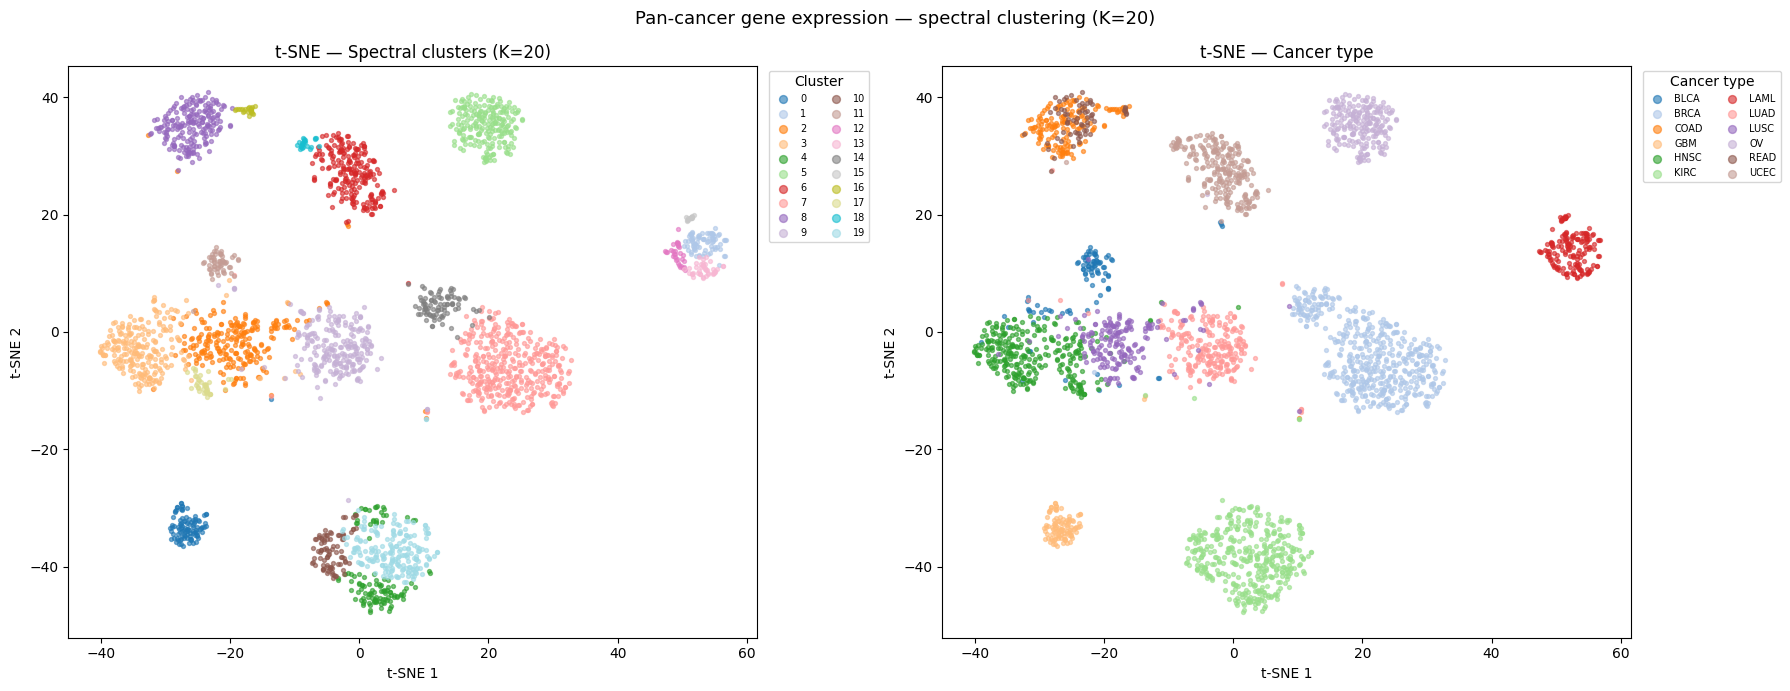

In [40]:
tsne_df = pd.DataFrame({
    "tsne1":   tsne_coords[:, 0],
    "tsne2":   tsne_coords[:, 1],
    "cluster": labels,
    "cancer":  ct["cancertype"].values,
})

palette_sc  = sns.color_palette("tab20", K)
cancer_types = sorted(tsne_df["cancer"].unique())
palette_ct  = sns.color_palette("tab20", len(cancer_types))
ct_color    = {t: palette_ct[i] for i, t in enumerate(cancer_types)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel A: spectral clusters ---
ax = axes[0]
for k in range(K):
    mask = tsne_df["cluster"] == k
    ax.scatter(tsne_df.loc[mask, "tsne1"], tsne_df.loc[mask, "tsne2"],
               s=8, alpha=0.6, color=palette_sc[k], label=str(k))
ax.set_title(f"t-SNE — Spectral clusters (K={K})", fontsize=12)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(title="Cluster", markerscale=2, fontsize=7,
          bbox_to_anchor=(1.01, 1), loc="upper left", ncol=2)

# --- Panel B: cancer type ---
ax = axes[1]
for t in cancer_types:
    mask = tsne_df["cancer"] == t
    ax.scatter(tsne_df.loc[mask, "tsne1"], tsne_df.loc[mask, "tsne2"],
               s=8, alpha=0.6, color=ct_color[t], label=t)
ax.set_title("t-SNE — Cancer type", fontsize=12)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(title="Cancer type", markerscale=2, fontsize=7,
          bbox_to_anchor=(1.01, 1), loc="upper left", ncol=2)

plt.suptitle("Pan-cancer gene expression — spectral clustering (K=20)", fontsize=13)
plt.tight_layout()
plt.show()

## Cancer Type Composition per Spectral Cluster

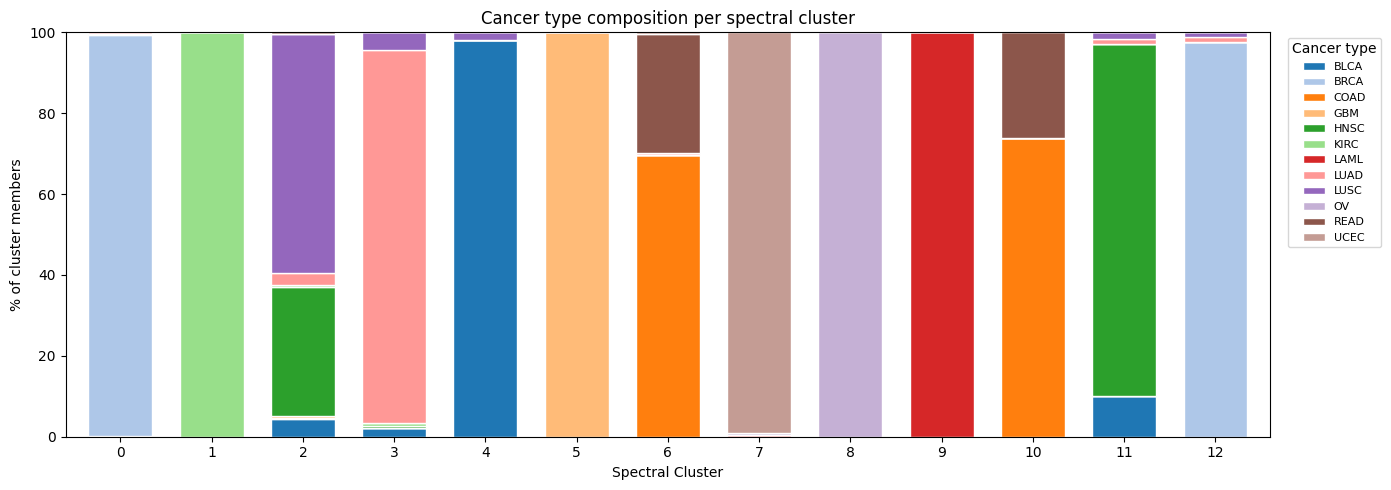

Adjusted Rand Index (spectral cluster vs cancer type): 0.8305


In [18]:
ct_cluster = pd.crosstab(
    tsne_df["cancer"],
    tsne_df["cluster"].rename("Cluster"),
    normalize="columns"
) * 100

fig, ax = plt.subplots(figsize=(14, 5))
ct_cluster.T.plot(kind="bar", stacked=True, ax=ax,
                  color=[ct_color[t] for t in ct_cluster.index],
                  width=0.7, edgecolor="white")
ax.set_xlabel("Spectral Cluster")
ax.set_ylabel("% of cluster members")
ax.set_title("Cancer type composition per spectral cluster")
ax.legend(title="Cancer type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

ari = adjusted_rand_score(ct["cancertype"].values, labels)
print(f"Adjusted Rand Index (spectral cluster vs cancer type): {ari:.4f}")

## Cancer Type × Cluster Heatmap (Absolute Counts)

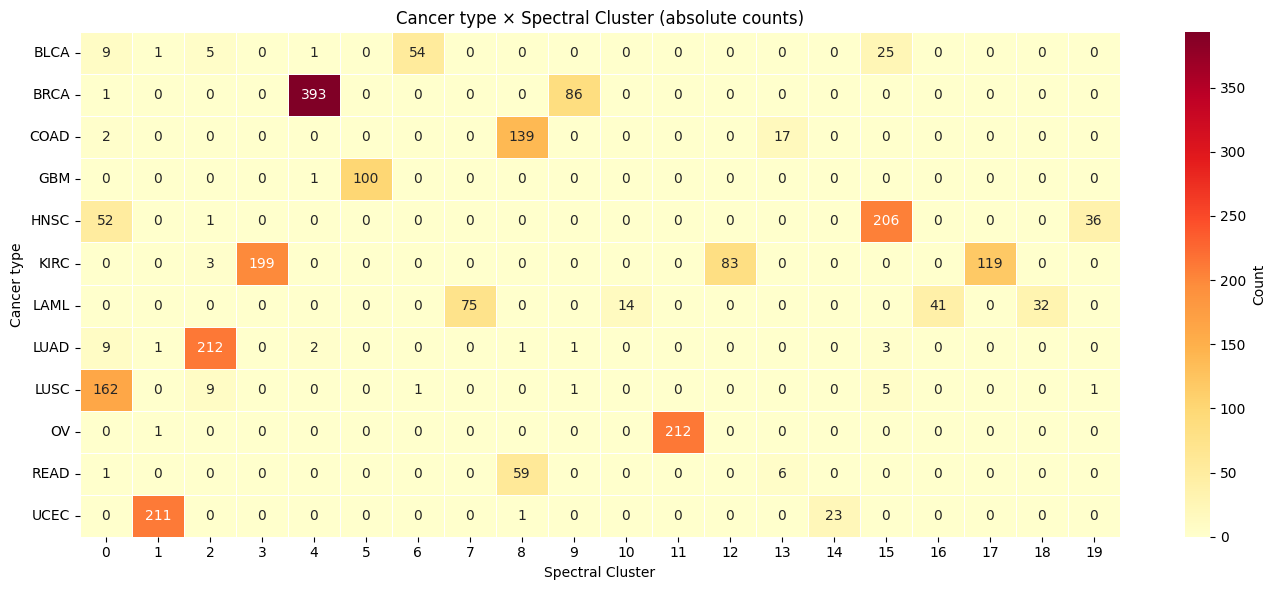

In [8]:
ct_counts = pd.crosstab(
    tsne_df["cancer"],
    tsne_df["cluster"].rename("Cluster")
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(ct_counts, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Count"})
ax.set_title("Cancer type × Spectral Cluster (absolute counts)")
ax.set_xlabel("Spectral Cluster")
ax.set_ylabel("Cancer type")
plt.tight_layout()
plt.show()

## Cluster Sizes

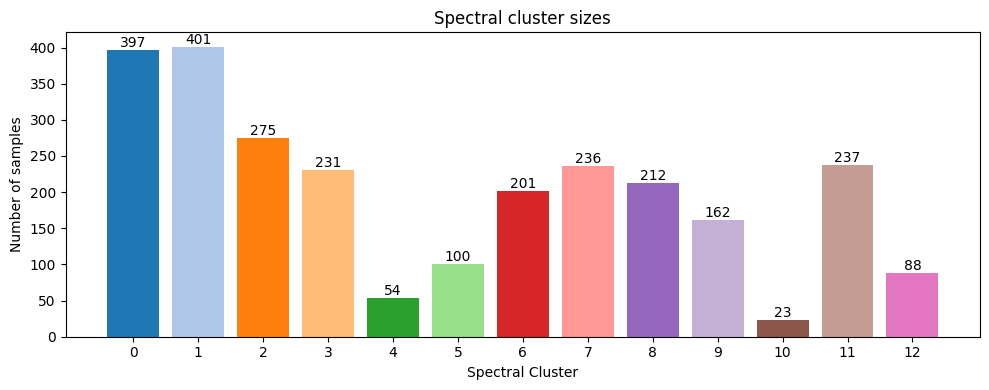

In [19]:
sizes = pd.Series(counts, index=unique, name="n_samples").sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(sizes.index.astype(str), sizes.values,
              color=[palette_sc[k] for k in sizes.index])
ax.bar_label(bars)
ax.set_xlabel("Spectral Cluster")
ax.set_ylabel("Number of samples")
ax.set_title("Spectral cluster sizes")
plt.tight_layout()
plt.show()

---

## TiM3 Model: Initialization from Spectral Clustering

Convert gene expression values to **item rankings** (each sample's genes ordered from highest to lowest expression), then initialize the Tied Bayesian Mallows Mixture Model (TiM3) via `init_spectral_with_z`, which performs spectral clustering in **ranking space** (Kendall-agreement similarity) to form the initial block structure and cluster assignments.

> **Note:** `init_spectral_with_z` builds a 800×800 pairwise ranking-agreement matrix — allow ~1–3 min.


In [20]:
import sys
sys.path.insert(0, ".")
from model import MixtureRankingModel
from model.initialization import init_spectral_with_z

# Convert gene expression (N × n_genes) to strict rankings.
# ranking[i] = list of gene indices sorted from highest to lowest expression.
# np.argsort gives positions that would sort ascending, so negate for descending.
ge_values = ge.values   # (N, n_genes)
rankings  = np.argsort(-ge_values, axis=1).tolist()   # list[N] of list[n_genes]

N_rk      = len(rankings)
n_items   = len(rankings[0])
print(f"Rankings: {N_rk} samples × {n_items} genes")


Rankings: 2617 samples × 1247 genes


In [41]:
import time

K_model = K   # 20 clusters (matches spectral clustering above)
MU      = 1e-4   # sparse Dirichlet prior — encourages cluster collapse toward fewer clusters

print(f"Running spectral init in ranking space (K={K_model}) ...")
print("(building 800×800 Kendall-agreement matrix — this takes ~1-3 min)")
t0 = time.perf_counter()

init_clusters, z_init = init_spectral_with_z(
    rankings    = rankings,
    n_clusters  = K_model,
    py_sampling = False,
    gamma       = 1.0,
    delta       = 0.5,
    seed        = SEED,
)

print(f"Spectral init done in {time.perf_counter() - t0:.1f}s")
print(f"Initial cluster sizes: { {c: z_init.count(c) for c in range(K_model)} }")


Running spectral init in ranking space (K=20) ...
(building 800×800 Kendall-agreement matrix — this takes ~1-3 min)
Spectral init done in 524.0s
Initial cluster sizes: {0: 175, 1: 162, 2: 92, 3: 77, 4: 168, 5: 134, 6: 160, 7: 199, 8: 191, 9: 231, 10: 87, 11: 129, 12: 98, 13: 83, 14: 156, 15: 64, 16: 145, 17: 54, 18: 148, 19: 64}


In [22]:
print("Building TiM3 model ...")
t0 = time.perf_counter()

model_base = MixtureRankingModel(
    rankings      = rankings,
    init_clusters = init_clusters,
    init_z        = z_init,
    init_mu       = [MU] * K_model,   # sparse prior — forces competition between clusters
    seed          = SEED,
    verbose       = True,
    init_theta    = 1.0,
)
print(f"Model built in {time.perf_counter() - t0:.1f}s")


Building TiM3 model ...
[Model] Initialized: N=2617 assessors, n=1247 items, C=13 clusters, n_pairs=776,881
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    2617×776,881  (7755.7 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
  Cluster 0: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 6: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 7: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 8: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 9: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 10: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 11: 624 blocks, theta=1.

---

## Early-Iteration Cluster Collapse Diagnostic

We run a **short diagnostic MCMC** (400 iterations, thin = 1, no burn-in discard) with **no temperature annealing** so we can observe the raw collapse dynamics.

### Why do clusters collapse?

After a random or spectral initialisation, many clusters may overlap or have poorly separated consensus rankings. The Dirichlet-Multinomial prior on cluster weights — especially with a sparse `mu` (< 1) — strongly penalises small clusters. If a cluster loses a few members early on, the reduced weight `τ_c` makes it even less attractive to nearby samples, creating a self-reinforcing collapse:

$$\tau_c \to 0 \;\Rightarrow\; P(z_i = c \mid \text{rest}) \propto \tau_c \cdot \exp(-\theta_c \,d_c(r_i)) \to 0 \;\Rightarrow\; \text{cluster empties}$$

Once a cluster has been empty for `COLLAPSE_PATIENCE` consecutive iterations it is permanently marked **dead** and removed from all future computations.


In [23]:
import copy

# --- diagnostic run: no annealing, all 400 iterations saved ---
N_DIAG = 400
N_BURN = 0

model_diag = copy.deepcopy(model_base)
model_diag.COLLAPSE_PATIENCE = 20   # default; mark dead after 20 empty iterations

print(f"Running diagnostic MCMC ({N_DIAG} iters, no annealing, thin=1) ...")
t0 = time.perf_counter()

_, samples_diag = model_diag.run_mcmc(
    n_iter                   = N_DIAG,
    burn_in                  = N_BURN,
    thin                     = 1,
    use_annealing            = False,
    use_py_prior             = False,
    include_order_prior      = False,
    save_samples             = True,
    save_tau                 = True,
    save_theta               = False,
    save_logp                = True,
    n_item_moves_per_cluster = 1,
    a_theta                  = 2,
    b_theta                  = 1,
    theta_jump               = 5,
)
elapsed = time.perf_counter() - t0
print(f"Done in {elapsed:.1f}s  ({elapsed/N_DIAG*1000:.0f} ms/iter)")
print(f"Dead clusters after {N_DIAG} iters: {model_diag._dead_clusters}")


Running diagnostic MCMC (400 iters, no annealing, thin=1) ...

[MCMC] Starting run: n_iter=400, burn_in=0, thin=1, theta_jump=5
[MCMC] Item moves per cluster: 1
[MCMC] Will save 400 iterations after burn-in

[Model] Clusters permanently retired (collapsed): [7, 11]  (total dead: 2/13)
[Model] Clusters permanently retired (collapsed): [5, 12]  (total dead: 4/13)
[Model] Clusters permanently retired (collapsed): [1, 2, 9]  (total dead: 7/13)
[MCMC]   10.2% | iter     41/400 |   103.5s elapsed | ETA  15.1 min
[Model] Clusters permanently retired (collapsed): [6]  (total dead: 8/13)
[Model] Clusters permanently retired (collapsed): [0, 4, 8, 10]  (total dead: 12/13)
[MCMC]   25.2% | iter    101/400 |   105.1s elapsed | ETA   5.2 min
[MCMC]   50.2% | iter    201/400 |   107.0s elapsed | ETA   1.8 min
[MCMC]   75.2% | iter    301/400 |   109.1s elapsed | ETA   0.6 min
[MCMC]   90.2% | iter    361/400 |   110.3s elapsed | ETA   0.2 min
[MCMC]  100.0% | iter    400/400 |   110.9s elapsed | ETA

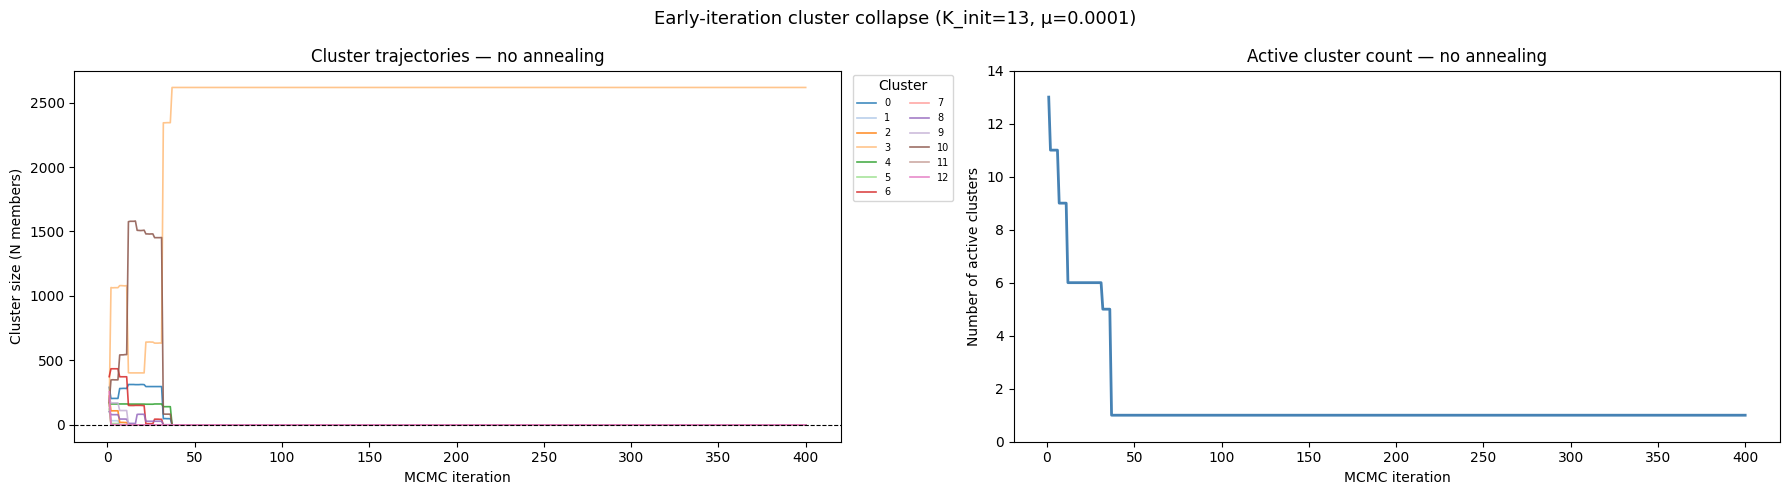

First collapse event: iteration 2
Active clusters at iteration 400: 1


In [24]:
def extract_cluster_sizes(z_samples, K):
    """Return (T, K) array of cluster sizes per saved iteration."""
    z_arr  = np.array(z_samples, dtype=int)   # (T, N)
    T      = z_arr.shape[0]
    sizes  = np.zeros((T, K), dtype=int)
    for t in range(T):
        u, c = np.unique(z_arr[t], return_counts=True)
        sizes[t, u] = c
    return sizes

sizes_diag = extract_cluster_sizes(samples_diag.z_samples, K_model)
iters_diag = np.arange(1, N_DIAG + 1)

# --- plot ---
palette_diag = sns.color_palette("tab20", K_model)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: absolute cluster sizes over iterations
ax = axes[0]
for k in range(K_model):
    ax.plot(iters_diag, sizes_diag[:, k], lw=1.2, alpha=0.85,
            color=palette_diag[k], label=str(k))
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("MCMC iteration")
ax.set_ylabel("Cluster size (N members)")
ax.set_title("Cluster trajectories — no annealing")
ax.legend(title="Cluster", ncol=2, fontsize=7, markerscale=1.5,
          bbox_to_anchor=(1.01, 1), loc="upper left")

# Right: number of non-empty (alive) clusters per iteration
alive_per_iter = (sizes_diag > 0).sum(axis=1)
ax = axes[1]
ax.plot(iters_diag, alive_per_iter, color="steelblue", lw=2)
ax.set_xlabel("MCMC iteration")
ax.set_ylabel("Number of active clusters")
ax.set_title("Active cluster count — no annealing")
ax.set_ylim(0, K_model + 1)

plt.suptitle(f"Early-iteration cluster collapse (K_init={K_model}, μ={MU})", fontsize=13)
plt.tight_layout()
plt.show()

# Summary
first_collapse = np.where(alive_per_iter < K_model)[0]
print(f"First collapse event: iteration {first_collapse[0]+1 if len(first_collapse) else 'none'}")
print(f"Active clusters at iteration {N_DIAG}: {alive_per_iter[-1]}")


In [25]:
# Detailed collapse timeline: when did each cluster first reach 0?
print("Cluster collapse timeline (no annealing):")
print(f"{'Cluster':>10}  {'First empty iter':>18}  {'Final size':>12}")
for k in range(K_model):
    empty_iters = np.where(sizes_diag[:, k] == 0)[0]
    first_empty = empty_iters[0] + 1 if len(empty_iters) else "—"
    final_size  = sizes_diag[-1, k]
    print(f"{k:>10}  {str(first_empty):>18}  {final_size:>12}")


Cluster collapse timeline (no annealing):
   Cluster    First empty iter    Final size
         0                  37             0
         1                  12             0
         2                  12             0
         3                   —          2617
         4                  37             0
         5                   7             0
         6                  32             0
         7                   2             0
         8                  37             0
         9                  12             0
        10                  37             0
        11                   2             0
        12                   7             0


---

## Mitigation: Temperature Annealing

**Temperature annealing** multiplies each cluster's concentration parameter $\theta_c$ by a temperature coefficient $T(t) \in [T_\text{min}, 1]$ that starts low and rises to 1 over the burn-in period.

$$\tilde{\theta}_c(t) = T(t) \cdot \theta_c$$

A lower $T$ flattens the per-cluster likelihoods:

$$\log p(r_i \mid c) \approx -\tilde{\theta}_c \cdot d_c(r_i) - \log Z(\tilde{\theta}_c, \text{blocks}_c)$$

This makes all clusters equally plausible early on, so the sampler can freely redistribute samples before the consensus rankings sharpen. We use a **plateau schedule**: hold at $T_\text{min}$ for the first 40% of burn-in, then ramp linearly to 1.


In [26]:
BURN_IN_ANNEAL = 200   # annealing ramps over the first 200 iterations
T_MIN         = 0.1   # start very flat — clusters nearly indistinguishable
T_MAX         = 1.0   # end at true posterior temperature

model_anneal = copy.deepcopy(model_base)

print(f"Running annealed MCMC ({N_DIAG} iters, burn_in={BURN_IN_ANNEAL}, plateau schedule) ...")
t0 = time.perf_counter()

_, samples_anneal = model_anneal.run_mcmc(
    n_iter                    = N_DIAG,
    burn_in                   = BURN_IN_ANNEAL,
    thin                      = 1,
    use_annealing             = True,
    annealing_schedule_type   = "plateau",
    annealing_plateau_frac    = 0.4,   # hold T_min for first 40% of burn-in
    temp_min                  = T_MIN,
    temp_max                  = T_MAX,
    use_py_prior              = False,
    include_order_prior       = False,
    save_samples              = True,
    save_tau                  = True,
    save_theta                = False,
    save_logp                 = True,
    n_item_moves_per_cluster  = 1,
    a_theta                   = 2,
    b_theta                   = 1,
    theta_jump                = 5,
)
elapsed = time.perf_counter() - t0
print(f"Done in {elapsed:.1f}s")
print(f"Dead clusters after {N_DIAG} iters: {model_anneal._dead_clusters}")


Running annealed MCMC (400 iters, burn_in=200, plateau schedule) ...

[MCMC] Starting run: n_iter=400, burn_in=200, thin=1, theta_jump=5
[MCMC] Item moves per cluster: 1
[MCMC] Will save 200 iterations after burn-in

[MCMC]   10.2% | iter     41/400 |     6.9s elapsed | ETA   1.0 min
[MCMC]   25.2% | iter    101/400 |    10.8s elapsed | ETA   0.5 min
[Model] Clusters permanently retired (collapsed): [1, 2, 5, 7, 8, 9, 10, 11, 12]  (total dead: 9/13)
[MCMC]   50.2% | iter    201/400 |   381.4s elapsed | ETA   6.3 min
[MCMC]   75.2% | iter    301/400 |   423.6s elapsed | ETA   2.3 min
[MCMC]   90.2% | iter    361/400 |   438.2s elapsed | ETA   0.8 min
[MCMC]  100.0% | iter    400/400 |   444.5s elapsed | ETA   0.0 min

[MCMC] Run complete in 444.5s (7.41 min)
[MCMC] Final logp: -19646043.84 (min=-19691981.34, max=-19644924.29)
[MCMC] Acceptance rates (theta | blocks):
  Cluster 0: 20.0% | 97.2%
  Cluster 1: 33.3% | 92.2%
  Cluster 2: 52.4% | 87.3%
  Cluster 3: 23.8% | 96.8%
  Cluster 4: 

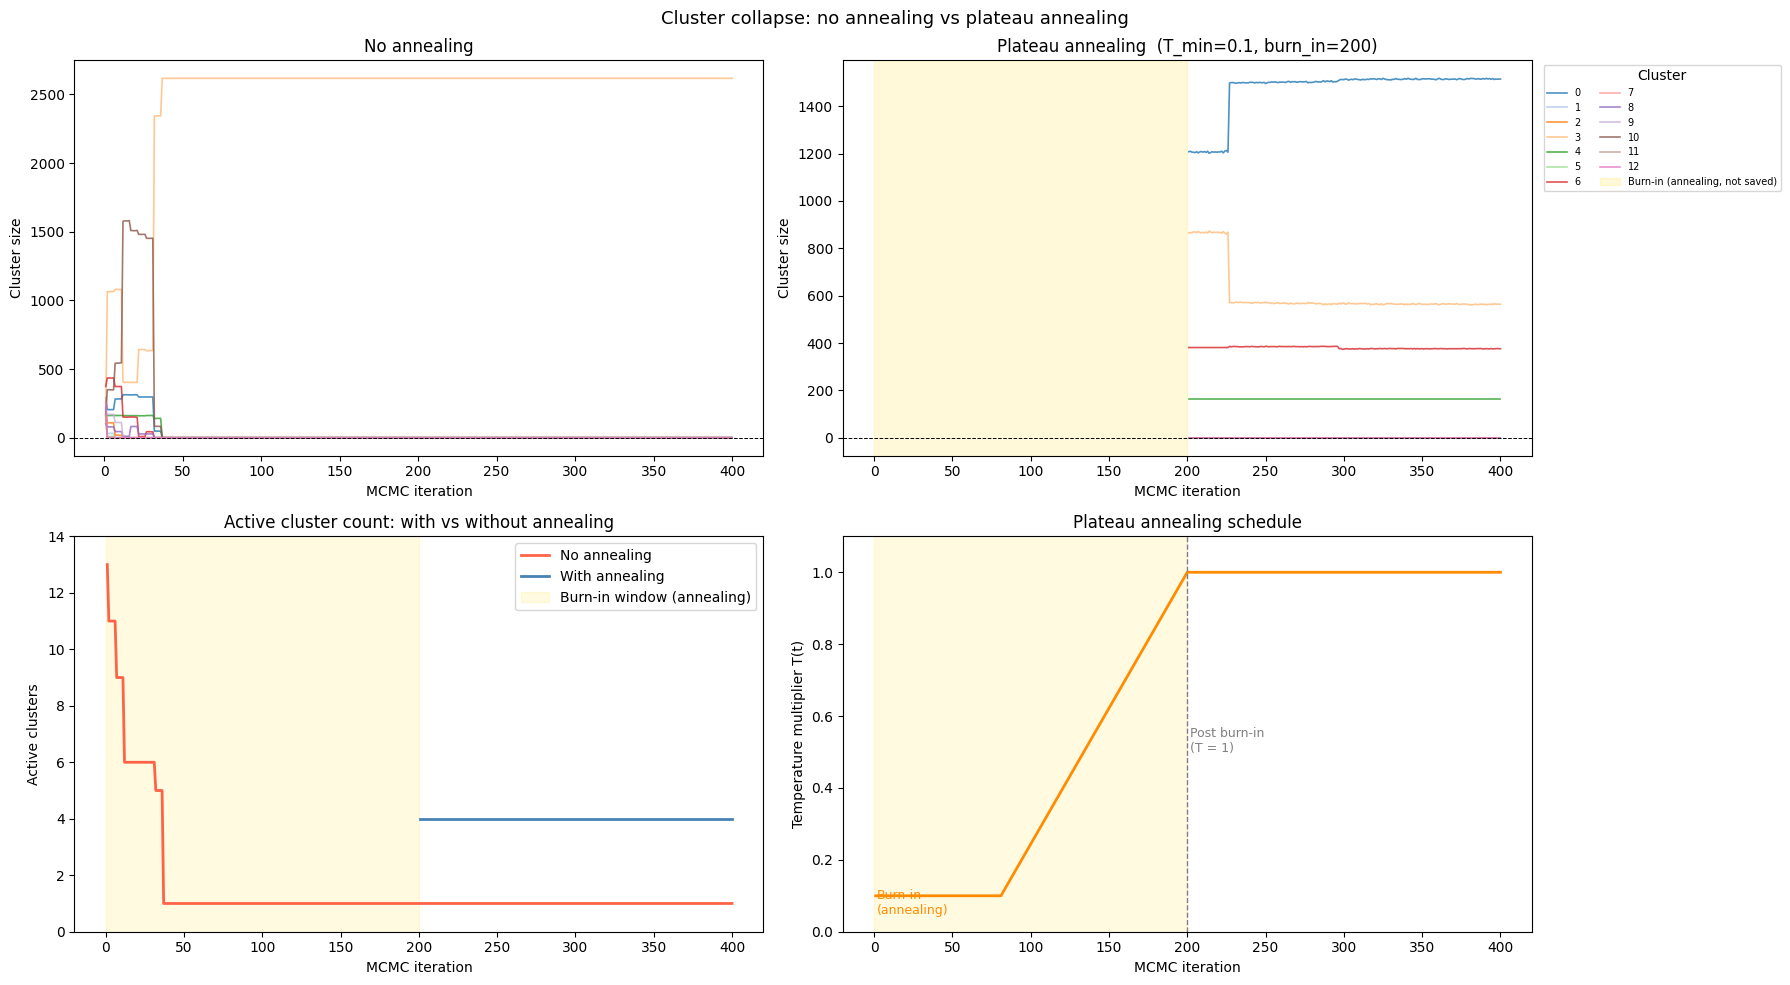


--- Active clusters at final saved iteration ---
  No annealing  (iter 400): 1
  With annealing (iter 400): 4


In [29]:
sizes_anneal = extract_cluster_sizes(samples_anneal.z_samples, K_model)

# Derive x-axes from actual saved-sample counts so the plot is correct
# regardless of whether burn_in discards within n_iter or adds extra iterations.
n_diag_saved   = sizes_diag.shape[0]
n_anneal_saved = sizes_anneal.shape[0]

# No-annealing run: iterations 1 … n_diag_saved
iters_diag_plot = np.arange(1, n_diag_saved + 1)

# Annealed run: saved samples start AFTER burn-in, so label them
# burn_in+1 … burn_in+n_anneal_saved so the x-axis is comparable.
iters_anneal_plot = np.arange(BURN_IN_ANNEAL + 1,
                               BURN_IN_ANNEAL + n_anneal_saved + 1)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# ── Row 1: cluster trajectories ────────────────────────────────────────────
for ax, (sizes, iters, title) in zip(axes[0], [
    (sizes_diag,   iters_diag_plot,   "No annealing"),
    (sizes_anneal, iters_anneal_plot, f"Plateau annealing  (T_min={T_MIN}, burn_in={BURN_IN_ANNEAL})"),
]):
    for k in range(K_model):
        ax.plot(iters, sizes[:, k], lw=1.2, alpha=0.8,
                color=palette_diag[k], label=str(k))
    ax.axhline(0, color="black", lw=0.7, ls="--")
    ax.set_xlabel("MCMC iteration")
    ax.set_ylabel("Cluster size")
    ax.set_title(title)

# Shade the burn-in window in the annealing panel (now correctly placed)
axes[0][1].axvspan(0, BURN_IN_ANNEAL, color="gold", alpha=0.15,
                   label="Burn-in (annealing, not saved)")
axes[0][1].legend(title="Cluster", ncol=2, fontsize=7,
                  bbox_to_anchor=(1.01, 1), loc="upper left")

# ── Row 2: active cluster count + temperature schedule ─────────────────────
alive_diag   = (sizes_diag   > 0).sum(axis=1)
alive_anneal = (sizes_anneal > 0).sum(axis=1)

ax = axes[1][0]
ax.plot(iters_diag_plot,   alive_diag,   color="tomato",    lw=2, label="No annealing")
ax.plot(iters_anneal_plot, alive_anneal, color="steelblue", lw=2, label="With annealing")
ax.axvspan(0, BURN_IN_ANNEAL, color="gold", alpha=0.12,
           label="Burn-in window (annealing)")
ax.set_xlabel("MCMC iteration")
ax.set_ylabel("Active clusters")
ax.set_title("Active cluster count: with vs without annealing")
ax.set_ylim(0, K_model + 1)
ax.legend()

# ── Plateau temperature schedule visualisation ─────────────────────────────
plateau_iters = int(0.4 * BURN_IN_ANNEAL)
ramp_iters    = BURN_IN_ANNEAL - plateau_iters
total_plot_iters = BURN_IN_ANNEAL + n_anneal_saved
schedule = (
    [T_MIN] * plateau_iters
    + [T_MIN + (T_MAX - T_MIN) * (t / max(1, ramp_iters - 1))
       for t in range(ramp_iters)]
    + [T_MAX] * n_anneal_saved
)
iters_schedule = np.arange(1, total_plot_iters + 1)

ax = axes[1][1]
ax.plot(iters_schedule, schedule, color="darkorange", lw=2)
ax.axvline(BURN_IN_ANNEAL, color="gray", ls="--", lw=1)
ax.axvspan(0, BURN_IN_ANNEAL, color="gold", alpha=0.12)
ax.set_xlabel("MCMC iteration")
ax.set_ylabel("Temperature multiplier T(t)")
ax.set_title("Plateau annealing schedule")
ax.set_ylim(0, 1.1)
ax.text(BURN_IN_ANNEAL + 2, 0.5, "Post burn-in\n(T = 1)", fontsize=9, color="gray")
ax.text(2, 0.05, "Burn-in\n(annealing)", fontsize=9, color="darkorange")

plt.suptitle("Cluster collapse: no annealing vs plateau annealing", fontsize=13)
plt.tight_layout()
plt.show()

print("\n--- Active clusters at final saved iteration ---")
print(f"  No annealing  (iter {iters_diag_plot[-1]}): {alive_diag[-1]}")
print(f"  With annealing (iter {iters_anneal_plot[-1]}): {alive_anneal[-1]}")


---

## Other Mitigation Strategies

Below is a summary of strategies for controlling early cluster collapse, from easiest to most involved:

| Strategy | How it works | Tuning knob | Trade-off |
|---|---|---|---|
| **Temperature annealing** | Flattens cluster likelihoods early; ramps to true posterior over burn-in | `temp_min`, `burn_in` | Longer effective burn-in needed |
| **Increase `mu`** | A symmetric Dirichlet prior with `mu ≥ 1` penalises empty clusters less (uniform at `mu=1`; prefer more clusters at `mu>1`) | `init_mu=[mu]*K` | Higher `mu` can keep spurious clusters alive |
| **Increase `COLLAPSE_PATIENCE`** | Keeps empty clusters alive longer, giving them a chance to be repopulated | `model.COLLAPSE_PATIENCE` | Wastes computation on truly dead clusters |
| **Fewer initial clusters** | Start with `K < 20`; clusters can only collapse to a smaller number | `K_model` | May miss structure if true K is large |
| **Warm restarts / multi-init** | Run multiple short chains and pick the best (highest log-posterior) | — | Multiplies compute cost by number of restarts |
| **Better block init** | Stronger spectral initialisation reduces overlap → fewer early collapses | `py_sampling`, `gamma`, `delta` | Longer initialisation time |

### What happens to log-posterior during collapse?

A sudden cluster collapse shows as a **sharp rise** in log-posterior (fewer clusters = less complexity = tighter fit per cluster), followed by a plateau. Annealing delays this spike, giving the sampler time to discover whether the collapsed cluster truly had no support.


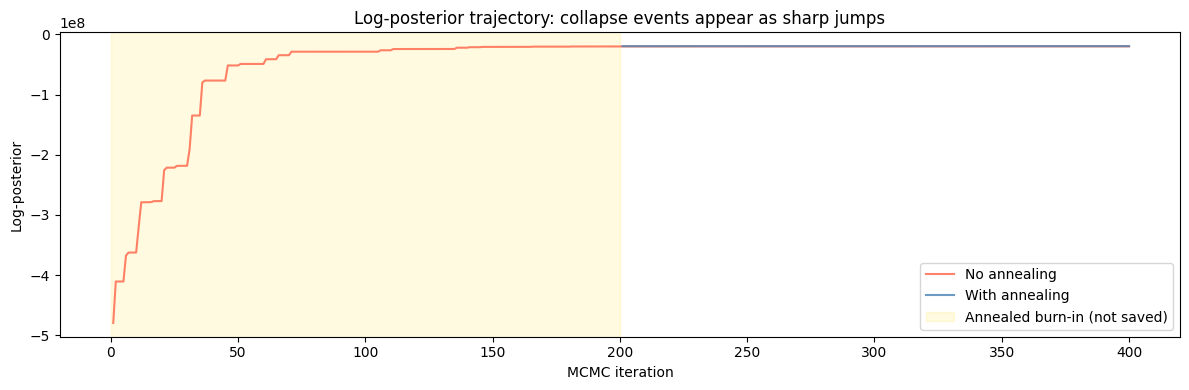

In [31]:
# Log-posterior trajectory comparison
logp_diag   = np.array(samples_diag.logp)
logp_anneal = np.array(samples_anneal.logp)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(iters_diag_plot,   logp_diag,   color="tomato",    lw=1.5, alpha=0.8, label="No annealing")
ax.plot(iters_anneal_plot, logp_anneal, color="steelblue", lw=1.5, alpha=0.8, label="With annealing")
ax.axvspan(0, BURN_IN_ANNEAL, color="gold", alpha=0.12, label="Annealed burn-in (not saved)")
ax.set_xlabel("MCMC iteration")
ax.set_ylabel("Log-posterior")
ax.set_title("Log-posterior trajectory: collapse events appear as sharp jumps")
ax.legend()
plt.tight_layout()
plt.show()


---

## Deep Dive: Block Rankings, Chain Stability & Sensitivity to μ

The previous section showed *that* clusters collapse. This section asks the harder questions:

| Question | What we measure |
|---|---|
| **What happens to the consensus block rankings?** | Number of blocks and Spearman correlation between consecutive draws per cluster |
| **Is the result stable?** | Extended run with rolling window statistics on cluster membership |
| **What if I run multiple chains?** | ARI between final cluster assignments across chains |
| **How does μ affect collapse?** | Sweep μ ∈ [10⁻⁵, 1] and record surviving cluster count |


### What happens to the consensus block rankings?

Each cluster maintains a **block partition** of the items (genes). Items within a block are treated as *tied* — the model cannot distinguish their relative order. The partition is updated via Metropolis-Hastings: at each iteration a block boundary is randomly split or merged.

**During collapse:**
1. As a cluster loses members, its likelihood surface flattens — the observation support for a fine-grained ordering disappears.
2. With fewer samples, block-merge moves are more readily accepted → the number of blocks (the *resolution* of the ranking) drops toward 1 (a single grand tie).
3. The consensus ordering itself becomes volatile — successive draws explore very different orderings because the data can no longer pin them down.

We track this with two diagnostics per cluster:
- **Number of blocks**: how many distinct tiers the current consensus has (1 = completely uninformative; n_items = strict total order).
- **Spearman ρ between consecutive draws**: 1 = ordering unchanged, low = high mixing / instability.


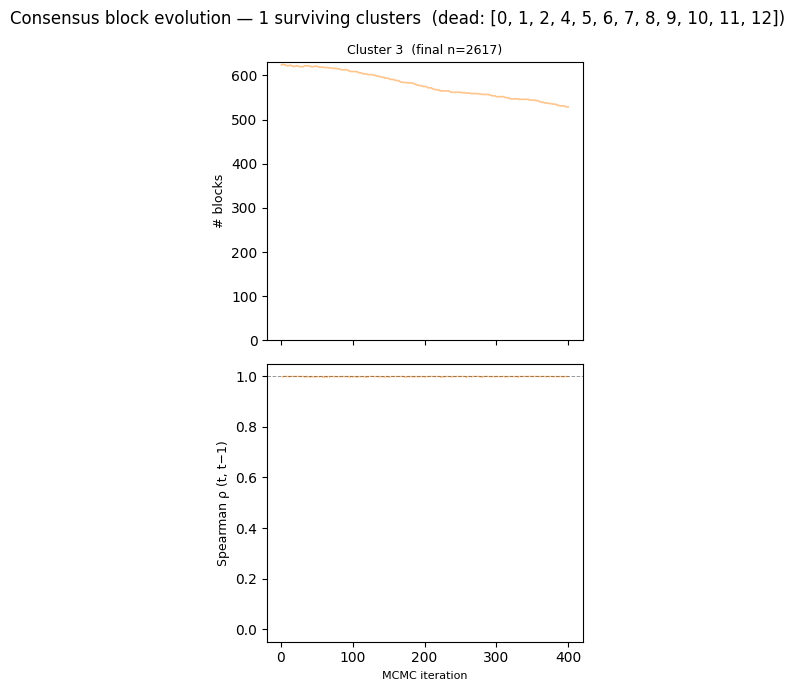


Surviving clusters : [3]
Dead clusters      : [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Cluster  3 — n_blocks  last 50 iters: 536.2 ± 4.6   mean Spearman ρ last 50: 1.000


In [32]:
from scipy.stats import spearmanr


def blocks_to_rank_vector(blocks, n_items):
    """Convert a block partition to a rank vector.

    Item in block b (0-indexed, 0 = highest ranked) gets value b.
    Returns an array of length n_items; items not covered get NaN.
    """
    rv = np.full(n_items, np.nan)
    for b_idx, block in enumerate(blocks):
        for item in block:
            if item < n_items:
                rv[item] = float(b_idx)
    return rv


# ── Collect per-cluster block diagnostics over the diagnostic run ──────────
alive_final = sorted(k for k in range(K_model) if sizes_diag[-1, k] > 0)
T_diag      = sizes_diag.shape[0]

rank_vecs    = {}   # k -> (T_diag, n_items), NaN where cluster is dead
n_blocks_ts  = {}   # k -> (T_diag,), NaN where cluster is dead

for k in range(K_model):
    rv_matrix = np.full((T_diag, n_items), np.nan)
    nb        = np.full(T_diag, np.nan)
    for t in range(T_diag):
        if sizes_diag[t, k] > 0:
            blks = samples_diag.blocks_samples[t][k]
            rv_matrix[t] = blocks_to_rank_vector(blks, n_items)
            nb[t]        = len(blks)
    rank_vecs[k]   = rv_matrix
    n_blocks_ts[k] = nb

# Spearman ρ between consecutive saved iterations (for alive intervals only)
spearman_ts = {}
for k in range(K_model):
    rv   = rank_vecs[k]
    corr = np.full(T_diag, np.nan)
    for t in range(1, T_diag):
        valid_prev = ~np.isnan(rv[t - 1])
        valid_cur  = ~np.isnan(rv[t])
        valid      = valid_prev & valid_cur
        if valid.sum() > 1:
            r, _ = spearmanr(rv[t - 1][valid], rv[t][valid])
            corr[t] = r
    spearman_ts[k] = corr

# ── Plot: n_blocks and Spearman ρ per cluster ──────────────────────────────
n_alive = len(alive_final)
dead_clusters = sorted(set(range(K_model)) - set(alive_final))

fig, axes = plt.subplots(2, n_alive, figsize=(4 * n_alive, 7), squeeze=False,
                          sharex=True)
fig.suptitle(
    f"Consensus block evolution — {n_alive} surviving clusters  "
    f"(dead: {dead_clusters})",
    fontsize=12,
)

for col, k in enumerate(alive_final):
    color = palette_diag[k]
    iters = iters_diag_plot          # 1 .. T_diag

    # Row 0: number of blocks
    ax0 = axes[0][col]
    ax0.plot(iters, n_blocks_ts[k], lw=1.2, color=color, alpha=0.85)
    ax0.set_title(f"Cluster {k}  (final n={sizes_diag[-1, k]})", fontsize=9)
    ax0.set_ylabel("# blocks", fontsize=8)
    ax0.set_ylim(bottom=0)

    # Row 1: Spearman ρ
    ax1 = axes[1][col]
    ax1.plot(iters[1:], spearman_ts[k][1:], lw=1.0, color=color, alpha=0.85)
    ax1.axhline(1.0, color="black", lw=0.7, ls="--", alpha=0.4)
    ax1.set_ylabel("Spearman ρ (t, t−1)", fontsize=8)
    ax1.set_xlabel("MCMC iteration", fontsize=8)
    ax1.set_ylim(-0.05, 1.05)

axes[0][0].set_ylabel("# blocks", fontsize=9)
axes[1][0].set_ylabel("Spearman ρ (t, t−1)", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nSurviving clusters : {alive_final}")
print(f"Dead clusters      : {dead_clusters}")
for k in alive_final:
    nb = n_blocks_ts[k]
    rh = spearman_ts[k]
    print(
        f"  Cluster {k:2d} — "
        f"n_blocks  last 50 iters: {np.nanmean(nb[-50:]):.1f} ± {np.nanstd(nb[-50:]):.1f}   "
        f"mean Spearman ρ last 50: {np.nanmean(rh[-50:]):.3f}"
    )


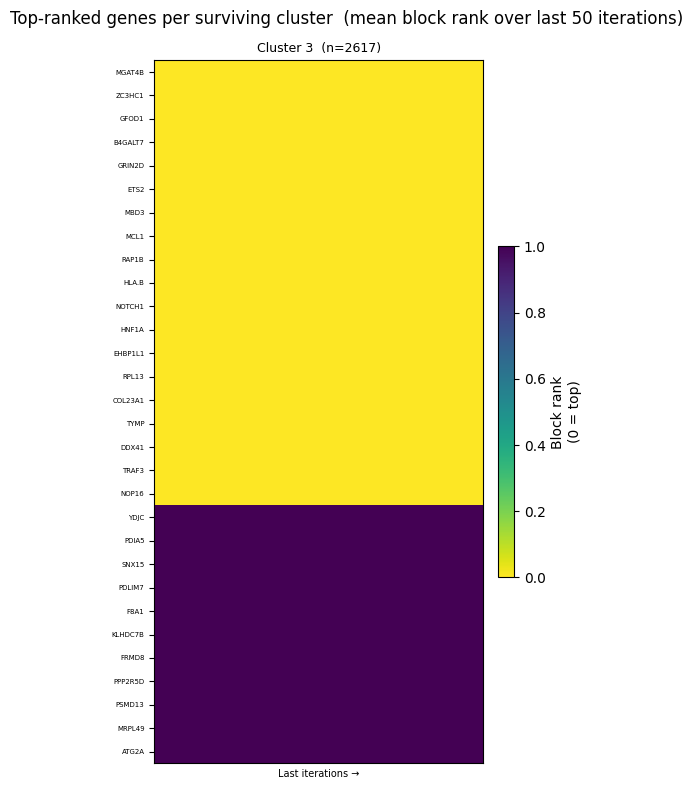

In [33]:
# ── Top-ranked genes per surviving cluster (averaged over last 50 iterations) ─
# For each surviving cluster compute the mean block rank across the last 50
# saved iterations, then show the 30 most consistently top-ranked genes as a
# heatmap. A low mean rank = gene consistently appears in a top-ranked block.

WINDOW = 50
gene_names = np.array(ge.columns)

fig, axes = plt.subplots(1, n_alive, figsize=(5 * n_alive, 8), squeeze=False)
fig.suptitle(
    f"Top-ranked genes per surviving cluster  "
    f"(mean block rank over last {WINDOW} iterations)",
    fontsize=12,
)

for col, k in enumerate(alive_final):
    rv_window = rank_vecs[k][-WINDOW:]          # (WINDOW, n_items)
    alive_mask = ~np.all(np.isnan(rv_window), axis=1)
    rv_valid   = rv_window[alive_mask]           # drop dead rows

    mean_rank = np.nanmean(rv_valid, axis=0)    # (n_items,)
    top30_idx = np.argsort(mean_rank)[:30]      # lowest mean rank = highest up

    heatmap_data = rv_valid[:, top30_idx].T     # (30, WINDOW')
    ax = axes[0][col]
    im = ax.imshow(
        heatmap_data,
        aspect="auto",
        cmap="viridis_r",        # dark = low rank = top ranked
        interpolation="nearest",
        vmin=0,
    )
    ax.set_title(f"Cluster {k}  (n={sizes_diag[-1, k]})", fontsize=9)
    ax.set_yticks(range(30))
    ax.set_yticklabels(gene_names[top30_idx], fontsize=5)
    ax.set_xlabel("Last iterations →", fontsize=7)
    ax.set_xticks([])
    plt.colorbar(im, ax=ax, label="Block rank\n(0 = top)", fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


---

### Stability: does the chain converge after collapse?

After the initial collapse phase, the surviving clusters should reach a **stationary regime**: membership sizes fluctuate around a stable mean and the Spearman correlation stays consistently high (the consensus ordering is well-determined).

We test this by running a longer annealed chain and tracking:
- **Rolling mean cluster size** (window = 100 iterations)
- **Rolling std of cluster size** (proxy for mixing / uncertainty)
- **Rolling alive-cluster count** (should plateau once all collapse events are done)

A fully converged chain shows flat rolling means with small, stationary variance.


In [ ]:
N_LONG         = 100000   # total iterations (increase for better convergence evidence)
BURN_IN_LONG   = 20000   # annealing burn-in (same schedule as before)
ROLL_WINDOW    = 50    # rolling-statistics window (saved iterations)
K = 20
MU = 1e-4 
SEED = 123

print(f"Running SpectralClustering with K={K} ...")
init_clusters, z_init = init_spectral_with_z(
    rankings    = rankings,
    n_clusters  = K,
    py_sampling = False,
    gamma       = 1.0,
    delta       = 0.5,
    seed        = SEED,
)
labels = sc.fit_predict(ge_pca)   # integer labels 0 .. K-1

unique, counts = np.unique(labels, return_counts=True)
print("Cluster sizes:")
for u, c in zip(unique, counts):
    print(f"  Cluster {u:2d}: {c} samples")

print("Building TiM3 model ...")
t0 = time.perf_counter()

model_base = MixtureRankingModel(
    rankings      = rankings,
    init_clusters = init_clusters,
    init_z        = z_init,
    init_mu       = [MU] * K,   # sparse prior — forces competition between clusters
    seed          = SEED,
    verbose       = True,
    init_theta    = 1.0,
)
print(f"Model built in {time.perf_counter() - t0:.1f}s")


model_long = copy.deepcopy(model_base)

print(f"Running long annealed chain  ({N_LONG} iters, burn_in={BURN_IN_LONG}) ...")
t0 = time.perf_counter()

_, samples_long = model_long.run_mcmc(
    n_iter                   = N_LONG,
    burn_in                  = BURN_IN_LONG,
    thin                     = 1,
    use_annealing            = True,
    annealing_schedule_type  = "plateau",
    annealing_plateau_frac   = 0.4,
    temp_min                 = T_MIN,
    temp_max                 = T_MAX,
    use_py_prior             = False,
    include_order_prior      = False,
    save_samples             = True,
    save_tau                 = True,
    save_theta               = False,
    save_logp                = True,
    n_item_moves_per_cluster = 20,
    a_theta                  = 2,
    b_theta                  = 1,
    theta_jump               = 1,
)
print(f"Done in {time.perf_counter()-t0:.1f}s   dead clusters: {model_long._dead_clusters}")

sizes_long = extract_cluster_sizes(samples_long.z_samples, K)
n_long_saved = sizes_long.shape[0]
iters_long = np.arange(BURN_IN_LONG + 1, BURN_IN_LONG + n_long_saved + 1)

# Rolling statistics helper
def rolling(arr, w):
    out = np.full_like(arr, np.nan, dtype=float)
    for i in range(w - 1, len(arr)):
        out[i] = arr[i - w + 1 : i + 1].mean()
    return out

alive_long = (sizes_long > 0).sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Panel 1: rolling alive cluster count
ax = axes[0]
ax.plot(iters_long, alive_long, lw=0.8, alpha=0.4, color="steelblue")
ax.plot(iters_long, rolling(alive_long.astype(float), ROLL_WINDOW),
        lw=2, color="steelblue", label=f"Rolling mean (w={ROLL_WINDOW})")
ax.set_xlabel("MCMC iteration")
ax.set_ylabel("Active clusters")
ax.set_title("Active cluster count — long run")
ax.set_ylim(0, K + 1)
ax.legend(fontsize=8)

# Panel 2: rolling mean cluster size for each surviving cluster
alive_long_final = sorted(k for k in range(K) if sizes_long[-1, k] > 0)
ax = axes[1]
for k in alive_long_final:
    rm = rolling(sizes_long[:, k].astype(float), ROLL_WINDOW)
    ax.plot(iters_long, rm, lw=1.3, alpha=0.85,
            color=palette_diag[k], label=str(k))
ax.set_xlabel("MCMC iteration")
ax.set_ylabel("Rolling mean size")
ax.set_title("Rolling mean cluster sizes")
ax.legend(title="Cluster", fontsize=7, ncol=2,
          bbox_to_anchor=(1.01, 1), loc="upper left")

# Panel 3: rolling std of cluster size (mixing indicator)
ax = axes[2]
for k in alive_long_final:
    std_arr = np.full(n_long_saved, np.nan)
    for i in range(ROLL_WINDOW - 1, n_long_saved):
        std_arr[i] = sizes_long[i - ROLL_WINDOW + 1 : i + 1, k].std()
    ax.plot(iters_long, std_arr, lw=1.0, alpha=0.8,
            color=palette_diag[k], label=str(k))
ax.set_xlabel("MCMC iteration")
ax.set_ylabel("Rolling std of size")
ax.set_title("Size fluctuation — should plateau if converged")
ax.legend(title="Cluster", fontsize=7, ncol=2,
          bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle(
    f"Convergence diagnostics — {N_LONG} iter annealed run  "
    f"(surviving clusters: {alive_long_final})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

logp_long = np.array(samples_long.logp)
print(f"\nLog-posterior — first 50 saved iters: {logp_long[:50].mean():.1f} ± {logp_long[:50].std():.1f}")
print(f"Log-posterior — last  50 saved iters: {logp_long[-50:].mean():.1f} ± {logp_long[-50:].std():.1f}")
print(f"Δ mean log-p (last - first): {logp_long[-50:].mean() - logp_long[:50].mean():.1f}  "
      f"(≈ 0 means converged)")


Running SpectralClustering with K=20 ...


c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Cluster sizes:
  Cluster  0: 100 samples
  Cluster  1: 75 samples
  Cluster  2: 237 samples
  Cluster  3: 239 samples
  Cluster  4: 118 samples
  Cluster  5: 212 samples
  Cluster  6: 214 samples
  Cluster  7: 397 samples
  Cluster  8: 200 samples
  Cluster  9: 229 samples
  Cluster 10: 86 samples
  Cluster 11: 55 samples
  Cluster 12: 32 samples
  Cluster 13: 41 samples
  Cluster 14: 88 samples
  Cluster 15: 14 samples
  Cluster 16: 23 samples
  Cluster 17: 37 samples
  Cluster 18: 23 samples
  Cluster 19: 197 samples
Building TiM3 model ...
[Model] Initialized: N=2617 assessors, n=1247 items, C=20 clusters, n_pairs=776,881
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    2617×776,881  (7755.7 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
  Cluster 0: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 624 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 6

---

### Multi-chain reproducibility

Running multiple independent chains from the **same spectral initialisation** but with different MCMC seeds tests whether the collapse outcome is reproducible or seed-dependent.

Two things can vary across chains:
1. **Which clusters survive** — do the same K clusters always win, or is it random?  
2. **How samples are assigned** — even if the same clusters survive, do chains agree on *which sample belongs to which cluster*?

We measure disagreement with the **Adjusted Rand Index (ARI)** between pairs of final cluster assignments. ARI ∈ [−1, 1]; 1 = identical partitions, 0 = random agreement.



[MCMC] Starting run: n_iter=2000, burn_in=1000, thin=1, theta_jump=5
[MCMC] Item moves per cluster: 5
[MCMC] Will save 1000 iterations after burn-in

[MCMC]   10.1% | iter    201/2000 |    33.7s elapsed | ETA   5.0 min
[MCMC]   25.1% | iter    501/2000 |   101.5s elapsed | ETA   5.1 min
[Model] Clusters permanently retired (collapsed): [0, 1, 5, 6, 8, 9, 10, 11, 12]  (total dead: 9/13)
[MCMC]   50.0% | iter   1001/2000 |   268.2s elapsed | ETA   4.5 min
[MCMC]   75.0% | iter   1501/2000 |   279.4s elapsed | ETA   1.5 min
[MCMC]   90.0% | iter   1801/2000 |   284.0s elapsed | ETA   0.5 min
[MCMC]  100.0% | iter   2000/2000 |   287.7s elapsed | ETA   0.0 min

[MCMC] Run complete in 287.7s (4.80 min)
[MCMC] Final logp: -19556886.06 (min=-19591493.29, max=-19556886.06)
[MCMC] Acceptance rates (theta | blocks):
  Cluster 0: 54.5% | 18.9%
  Cluster 1: 51.5% | 19.1%
  Cluster 2: 13.5% | 19.8%
  Cluster 3: 15.8% | 19.9%
  Cluster 4: 15.0% | 19.8%
  Cluster 5: 52.5% | 18.5%
  Cluster 6: 53.5% 

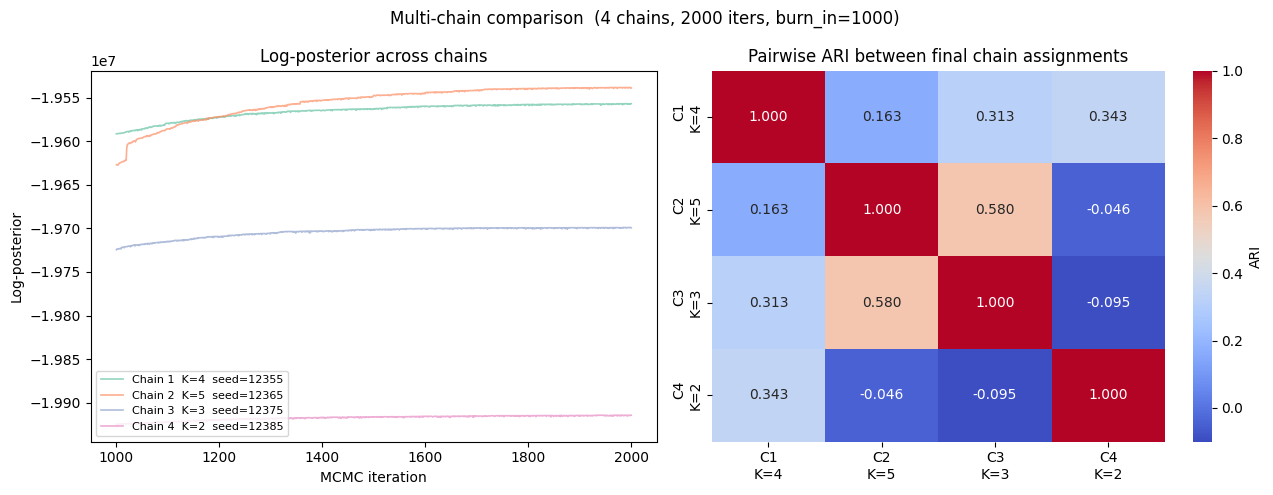


Mean pairwise ARI: 0.210
High ARI (> 0.8) → chains agree on which sample belongs to which cluster
Low  ARI (< 0.5) → collapse is non-deterministic; multi-init recommended


In [38]:
import random as stdlib_random

N_CHAINS   = 4                                # number of independent chains
N_CHAIN_IT = 2000                              # total iterations per chain
BURN_CHAIN = 1000                              # annealing burn-in per chain
SEED = 12345                                     # base seed for reproducibility
T_MAX = 1.0
T_MIN = 0.2                                     # start with very flat posterior to delay collapse
CHAIN_SEEDS = [SEED + 10 * (i + 1) for i in range(N_CHAINS)]

chain_results = []   # list of dicts: alive_k, final_z, logp_last50

for chain_idx, seed_c in enumerate(CHAIN_SEEDS):
    m = copy.deepcopy(model_base)
    m.rng = stdlib_random.Random(seed_c)     # replace the RNG with a new seed

    _, samp = m.run_mcmc(
        n_iter                   = N_CHAIN_IT,
        burn_in                  = BURN_CHAIN,
        thin                     = 1,
        use_annealing            = True,
        annealing_schedule_type  = "plateau",
        annealing_plateau_frac   = 0.4,
        temp_min                 = T_MIN,
        temp_max                 = T_MAX,
        use_py_prior             = False,
        include_order_prior      = False,
        save_samples             = True,
        save_tau                 = False,
        save_logp                = True,
        n_item_moves_per_cluster = 5,
        a_theta                  = 2,
        b_theta                  = 1,
        theta_jump               = 5,
    )
    sizes_c = extract_cluster_sizes(samp.z_samples, K_model)
    alive_c = sorted(k for k in range(K_model) if sizes_c[-1, k] > 0)
    logp_c  = np.array(samp.logp)
    # Final MAP assignment: use the last saved z sample
    final_z = np.array(samp.z_samples[-1])

    chain_results.append({
        "seed"       : seed_c,
        "alive_k"    : alive_c,
        "n_alive"    : len(alive_c),
        "final_z"    : final_z,
        "logp_last50": logp_c[-50:].mean(),
        "dead"       : m._dead_clusters,
        "logp"       : logp_c,
        "sizes"      : sizes_c,
    })
    print(f"  Chain {chain_idx+1} (seed={seed_c}): alive={alive_c}  "
          f"mean logp (last 50)={logp_c[-50:].mean():.1f}")

# ── Pairwise ARI matrix ────────────────────────────────────────────────────
all_final_z = [r["final_z"] for r in chain_results]
ari_matrix  = np.eye(N_CHAINS)
for i in range(N_CHAINS):
    for j in range(i + 1, N_CHAINS):
        a = adjusted_rand_score(all_final_z[i], all_final_z[j])
        ari_matrix[i, j] = a
        ari_matrix[j, i] = a

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: log-posterior trajectories for all chains
ax = axes[0]
chain_palette = sns.color_palette("Set2", N_CHAINS)
for i, r in enumerate(chain_results):
    n_saved  = len(r["logp"])
    iters_c  = np.arange(BURN_CHAIN + 1, BURN_CHAIN + n_saved + 1)
    ax.plot(iters_c, r["logp"], lw=1.2, alpha=0.7,
            color=chain_palette[i],
            label=f"Chain {i+1}  K={r['n_alive']}  seed={r['seed']}")
ax.set_xlabel("MCMC iteration")
ax.set_ylabel("Log-posterior")
ax.set_title("Log-posterior across chains")
ax.legend(fontsize=8)

# Panel 2: ARI heatmap
ax = axes[1]
chain_labels = [f"C{i+1}\nK={r['n_alive']}" for i, r in enumerate(chain_results)]
sns.heatmap(
    ari_matrix, annot=True, fmt=".3f", cmap="coolwarm",
    vmin=-0.1, vmax=1.0,
    xticklabels=chain_labels, yticklabels=chain_labels,
    ax=ax, cbar_kws={"label": "ARI"},
)
ax.set_title("Pairwise ARI between final chain assignments")

plt.suptitle(
    f"Multi-chain comparison  ({N_CHAINS} chains, {N_CHAIN_IT} iters, burn_in={BURN_CHAIN})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

print(f"\nMean pairwise ARI: {ari_matrix[np.triu_indices(N_CHAINS,k=1)].mean():.3f}")
print("High ARI (> 0.8) → chains agree on which sample belongs to which cluster")
print("Low  ARI (< 0.5) → collapse is non-deterministic; multi-init recommended")


---

### Effect of μ on cluster survival

`init_mu` controls the **Dirichlet prior** on cluster weights $\tau$. The prior is:

$$\tau \sim \text{Dir}(\mu_1, \ldots, \mu_K)$$

All $\mu_c = \mu$ (symmetric). This prior directly determines how much the model penalises empty clusters:

| μ value | Effect |
|---|---|
| μ ≪ 1 (e.g. 10⁻⁵) | Extremely sparse — each extra cluster is strongly penalised; collapse is rapid and aggressive |
| μ = 1 | Uniform prior on $\tau$ — no preference; collapse driven purely by likelihood |
| μ > 1 | Rich-get-richer reversed — model *prefers* spread across many clusters; collapse is suppressed |
| μ → ∞ | Forces equal cluster sizes ($\tau \to 1/K$) — no collapse at all |

We sweep μ over three orders of magnitude and record how many clusters survive after a short run.


In [37]:
MU_VALUES  = [1e-5, 1e-4, 1e-3, 0.1, 0.5, 1.0, 2.0]
N_MU_ITER  = 400    # short run per mu value
BURN_MU    = 200    # annealed burn-in per mu value

mu_results = []

for mu_val in MU_VALUES:
    m = MixtureRankingModel(
        rankings      = rankings,
        init_clusters = init_clusters,
        init_z        = z_init,
        init_mu       = [mu_val] * K_model,
        seed          = SEED,
        verbose       = False,
        init_theta    = 1.0,
    )
    _, samp = m.run_mcmc(
        n_iter                   = N_MU_ITER,
        burn_in                  = BURN_MU,
        thin                     = 1,
        use_annealing            = True,
        annealing_schedule_type  = "plateau",
        annealing_plateau_frac   = 0.4,
        temp_min                 = T_MIN,
        temp_max                 = T_MAX,
        use_py_prior             = False,
        include_order_prior      = False,
        save_samples             = True,
        save_tau                 = False,
        save_logp                = True,
        n_item_moves_per_cluster = 1,
        a_theta                  = 2,
        b_theta                  = 1,
        theta_jump               = 5,
    )
    sizes_mu   = extract_cluster_sizes(samp.z_samples, K_model)
    alive_mu   = int((sizes_mu[-1] > 0).sum())
    logp_mu    = np.array(samp.logp)

    mu_results.append({
        "mu"         : mu_val,
        "alive_k"    : alive_mu,
        "logp_mean"  : logp_mu[-50:].mean(),
        "sizes_end"  : sizes_mu[-50:].mean(axis=0),
        "alive_traj" : (sizes_mu > 0).sum(axis=1),
    })
    print(f"  μ={mu_val:.0e}  →  surviving clusters: {alive_mu}   "
          f"logp (last 50): {logp_mu[-50:].mean():.1f}")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
mu_labels  = [f"{r['mu']:.0e}" for r in mu_results]
alive_vals = [r["alive_k"]   for r in mu_results]
logp_vals  = [r["logp_mean"] for r in mu_results]

# Panel 1: alive clusters vs mu (log scale)
ax = axes[0]
ax.semilogx([r["mu"] for r in mu_results], alive_vals, "o-",
             color="steelblue", lw=2, ms=8)
ax.axhline(K_model, color="gray", ls="--", lw=1, label=f"K_init={K_model}")
ax.set_xlabel("μ (log scale)")
ax.set_ylabel("Surviving clusters")
ax.set_title("Effect of μ on cluster survival")
ax.set_ylim(0, K_model + 2)
ax.set_xticks([r["mu"] for r in mu_results])
ax.set_xticklabels(mu_labels, rotation=30, ha="right")
ax.legend()

# Panel 2: log-posterior vs mu
ax = axes[1]
ax.semilogx([r["mu"] for r in mu_results], logp_vals, "s-",
             color="tomato", lw=2, ms=8)
ax.set_xlabel("μ (log scale)")
ax.set_ylabel("Mean log-posterior (last 50 iters)")
ax.set_title("Log-posterior vs μ\n(higher = better fit, but may overfit)")
ax.set_xticks([r["mu"] for r in mu_results])
ax.set_xticklabels(mu_labels, rotation=30, ha="right")

# Panel 3: alive-cluster trajectories for each mu
ax = axes[2]
traj_palette = sns.color_palette("coolwarm_r", len(MU_VALUES))
for i, r in enumerate(mu_results):
    traj   = r["alive_traj"]
    n_traj = len(traj)
    itrs   = np.arange(BURN_MU + 1, BURN_MU + n_traj + 1)
    ax.plot(itrs, traj, lw=1.3, alpha=0.85,
            color=traj_palette[i], label=f"μ={r['mu']:.0e}")
ax.set_xlabel("MCMC iteration")
ax.set_ylabel("Active clusters")
ax.set_title("Collapse trajectory per μ value")
ax.set_ylim(0, K_model + 1)
ax.legend(fontsize=8, ncol=2)

plt.suptitle(
    f"μ sensitivity sweep  (K_init={K_model}, {N_MU_ITER} iter, burn_in={BURN_MU})",
    fontsize=12,
)
plt.tight_layout()
plt.show()


MemoryError: Unable to allocate 15.1 GiB for an array with shape (776881, 2617) and data type int64

---

## Greedy Consensus Recovery from Posterior Block Samples

Instead of using a single MAP block draw, we recover the consensus weak order by **averaging over the full posterior** and applying a principled greedy merging algorithm.

### Algorithm

1. **Pairwise preference matrix** $P[i,j]$ — fraction of posterior draws where item $i$ is in a higher-ranked block than item $j$.  Ties (same block in a draw) contribute $p = \tfrac{1}{2}$ to both $P[i,j]$ and $P[j,i]$, so $P[i,j] + P[j,i] = 1$ for all $i \neq j$.

2. **Initial strict ordering** — sort items descending by Borda score $B_i = \sum_j P[i,j]$.  Every item starts as its own singleton block.  Borda cycles are resolved automatically by the merge step.

3. **Greedy block merging** — iterate until convergence:
   - For each adjacent block pair $(B_a, B_b)$ in the current ordering, compute the *total* cross-block Kemeny disagreement:
     $$D_{\text{cross}}(B_a, B_b) = \sum_{i \in B_a,\, j \in B_b} P[j, i]$$
   - Find the pair with the highest $D_{\text{cross}}$ that exceeds the **theoretical likelihood threshold**:
     $$D_{\text{cross}} > \frac{1}{\hat{\theta}} \log \frac{\binom{s_a+s_b}{s_a}}{\binom{s_a+s_b}{s_a}_{e^{-\hat{\theta}}}}$$
     where $\binom{n}{k}_q$ is the q-binomial (ratio of Mallows normalising constants: merged $Z$ / separate $Z$).
   - Merge that pair; repeat.  Stop when no adjacent pair exceeds its threshold.

The threshold decreases with $\hat{\theta}$: a concentrated cluster needs very little cross-block disagreement to justify keeping items separate, while a diffuse cluster readily merges.


In [ ]:
from model.summaries import (
    greedy_consensus_recovery,
    build_posterior_pairwise_matrix,
    merge_threshold,
)

# ── Apply greedy consensus recovery to every surviving cluster ────────────────
# We use the long-run posterior (samples_long) which has the most reliable
# block samples.  thin=10 reduces the matrix build to ~8 000 samples while
# keeping statistical accuracy high.

THIN = 10   # use every 10th posterior sample for the pairwise matrix

consensus_results = {}   # cluster_idx → {"blocks": ..., "info": ...}

for c in alive_long_final:
    # Extract block samples for this cluster from the long run.
    # blocks_samples[t][c] is the block structure at draw t for cluster c.
    bsamp_c = [samples_long.blocks_samples[t][c]
                for t in range(len(samples_long.blocks_samples))]

    # Use current model theta for the cluster (MAP-like estimate).
    theta_c = model_long.clusters[c].theta

    blocks_hat, info = greedy_consensus_recovery(
        bsamp_c,
        theta    = theta_c,
        n_items  = n_items,
        thin     = THIN,
    )
    consensus_results[c] = {"blocks": blocks_hat, "info": info, "theta": theta_c}

    n_blk      = len(blocks_hat)
    n_merges   = len(info["merge_history"])
    n_cycles   = info["n_cycles"]
    print(f"Cluster {c:2d}  θ={theta_c:.3f}  "
          f"→  {n_items} items  "
          f"→  {n_blk} blocks  "
          f"({n_merges} merges performed"
          f"{', ' + str(n_cycles) + ' Borda cycles broken by merging' if n_cycles else ''})")


In [ ]:
# ── Visualise: pairwise matrix + recovered block structure ───────────────────
# For each surviving cluster, show:
#   Left  — pairwise preference heatmap P (reordered by Borda score).
#           Blue = strong preference for row > col; red = col > row.
#           White dashed lines mark recovered block boundaries.
#   Right — D_cross vs threshold for each adjacent block pair in the final
#           consensus (should all be below their threshold lines).

n_c = len(alive_long_final)
fig, axes = plt.subplots(n_c, 2, figsize=(12, 5 * n_c), squeeze=False)
fig.suptitle(
    "Greedy consensus recovery — posterior pairwise matrix & merge diagnostics",
    fontsize=13,
)

for row, c in enumerate(alive_long_final):
    res   = consensus_results[c]
    info  = res["info"]
    blocks_hat = res["blocks"]
    theta_c    = res["theta"]

    P            = info["P"]
    ordered_items = info["ordered_items"]   # Borda ordering (all items)
    d_final      = info["d_cross_final"]
    thr_final    = info["threshold_final"]

    # Reorder P by Borda score for display
    P_ord = P[np.ix_(ordered_items, ordered_items)]

    # ── Left: pairwise preference heatmap ──────────────────────────────────
    ax = axes[row][0]
    im = ax.imshow(P_ord, cmap="RdBu_r", vmin=0, vmax=1,
                   aspect="auto", interpolation="nearest")
    plt.colorbar(im, ax=ax, label="P[i,j]  (1 = i always above j)",
                 fraction=0.046, pad=0.04)

    # Draw block boundaries in Borda-ordered space
    # Compute cumulative block sizes to find boundary positions
    cum = 0
    boundaries = []
    for blk in blocks_hat:
        cum += len(blk)
        boundaries.append(cum - 0.5)
    boundaries = boundaries[:-1]   # omit last (edge of matrix)

    for b in boundaries:
        ax.axhline(b, color="white", lw=1.2, ls="--", alpha=0.8)
        ax.axvline(b, color="white", lw=1.2, ls="--", alpha=0.8)

    ax.set_title(
        f"Cluster {c}  (θ={theta_c:.3f})  →  {len(blocks_hat)} blocks",
        fontsize=10,
    )
    ax.set_xlabel("Item j  (Borda order →)", fontsize=8)
    ax.set_ylabel("Item i  (Borda order ↓)", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

    # ── Right: D_cross vs threshold per adjacent block pair ────────────────
    ax2 = axes[row][1]
    if d_final:
        x = np.arange(len(d_final))
        ax2.bar(x, d_final,   color="steelblue", alpha=0.7, label="$D_{\\mathrm{cross}}$")
        ax2.bar(x, thr_final, color="tomato",    alpha=0.5, label="Threshold", zorder=3,
                fill=False, edgecolor="tomato", linewidth=1.5)
        ax2.step(x, thr_final, where="mid", color="tomato", lw=1.5, zorder=4)
        ax2.set_xlabel("Adjacent block pair index", fontsize=8)
        ax2.set_ylabel("$D_{\\mathrm{cross}}$  /  threshold", fontsize=8)
        ax2.set_title(
            f"Final D_cross ≤ threshold  "
            f"(all {len(d_final)} pairs satisfied)",
            fontsize=9,
        )
        ax2.legend(fontsize=8)
    else:
        ax2.text(0.5, 0.5, "Single block\n(everything merged)",
                 ha="center", va="center", transform=ax2.transAxes, fontsize=10)
        ax2.set_axis_off()

    # Merge history summary
    hist = info["merge_history"]
    if hist:
        last = hist[-1]
        print(
            f"  Cluster {c}: {len(hist)} merges.  "
            f"Last merge — D_cross={last['d_cross']:.4f}  "
            f"threshold={last['threshold']:.4f}  "
            f"block sizes ({len(last['block_a'])}, {len(last['block_b'])})"
        )

plt.tight_layout()
plt.show()


In [ ]:
# ── Block size distributions and merge history ──────────────────────────────

fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4), squeeze=False)
fig.suptitle("Recovered block sizes per cluster", fontsize=12)

for col, c in enumerate(alive_long_final):
    blocks_hat = consensus_results[c]["blocks"]
    block_sizes = [len(b) for b in blocks_hat]

    ax = axes[0][col]
    ax.bar(range(len(block_sizes)), block_sizes,
           color=palette_diag[c], alpha=0.8, edgecolor="white")
    ax.set_xlabel("Block rank (0 = highest)", fontsize=8)
    ax.set_ylabel("Block size", fontsize=8)
    ax.set_title(
        f"Cluster {c}  —  {len(block_sizes)} blocks\n"
        f"sizes: min={min(block_sizes)}, max={max(block_sizes)}, "
        f"mean={np.mean(block_sizes):.1f}",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# ── Merge history table ──────────────────────────────────────────────────────
for c in alive_long_final:
    hist = consensus_results[c]["info"]["merge_history"]
    if not hist:
        print(f"Cluster {c}: no merges performed (all singletons kept).")
        continue
    print(f"\nCluster {c} — {len(hist)} merge(s)  (θ={consensus_results[c]['theta']:.3f}):")
    print(f"  {'Step':>4}  {'Pos':>4}  {'D_cross':>9}  {'Threshold':>10}  "
          f"{'Blk sizes':>12}  {'n_blks→'}") 
    for step, h in enumerate(hist):
        sa, sb = len(h["block_a"]), len(h["block_b"])
        print(f"  {step+1:>4}  {h['position']:>4}  {h['d_cross']:>9.4f}  "
              f"{h['threshold']:>10.4f}  ({sa:>2},{sb:>2}) → {sa+sb}  "
              f"  {h['n_blk_before']:>4} → {h['n_blk_before']-1}")
